<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Gal_stone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [2]:
# ─── Imports ───
import warnings, time, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ─── Plot Configuration ───
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Load Gallstone Dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/gallstone.csv")

print("Dataset Shape :", df.shape)
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution")
print(df["Gallstone Status"].value_counts())

Dataset Shape : (319, 39)
   Gallstone Status  Age  Gender  Comorbidity  Coronary Artery Disease (CAD)  \
0                 0   50       0            0                              0   
1                 0   47       0            1                              0   
2                 0   61       0            0                              0   
3                 0   41       0            0                              0   
4                 0   42       0            0                              0   

   Hypothyroidism  Hyperlipidemia  Diabetes Mellitus (DM)  Height  Weight  \
0               0               0                       0     185    92.8   
1               0               0                       0     176    94.5   
2               0               0                       0     171    91.1   
3               0               0                       0     168    67.7   
4               0               0                       0     178    89.6   

   ...  High Density Lipoprote

In [5]:
target = "Gallstone Status"

X = df.drop(columns=[target])
y = df[target]

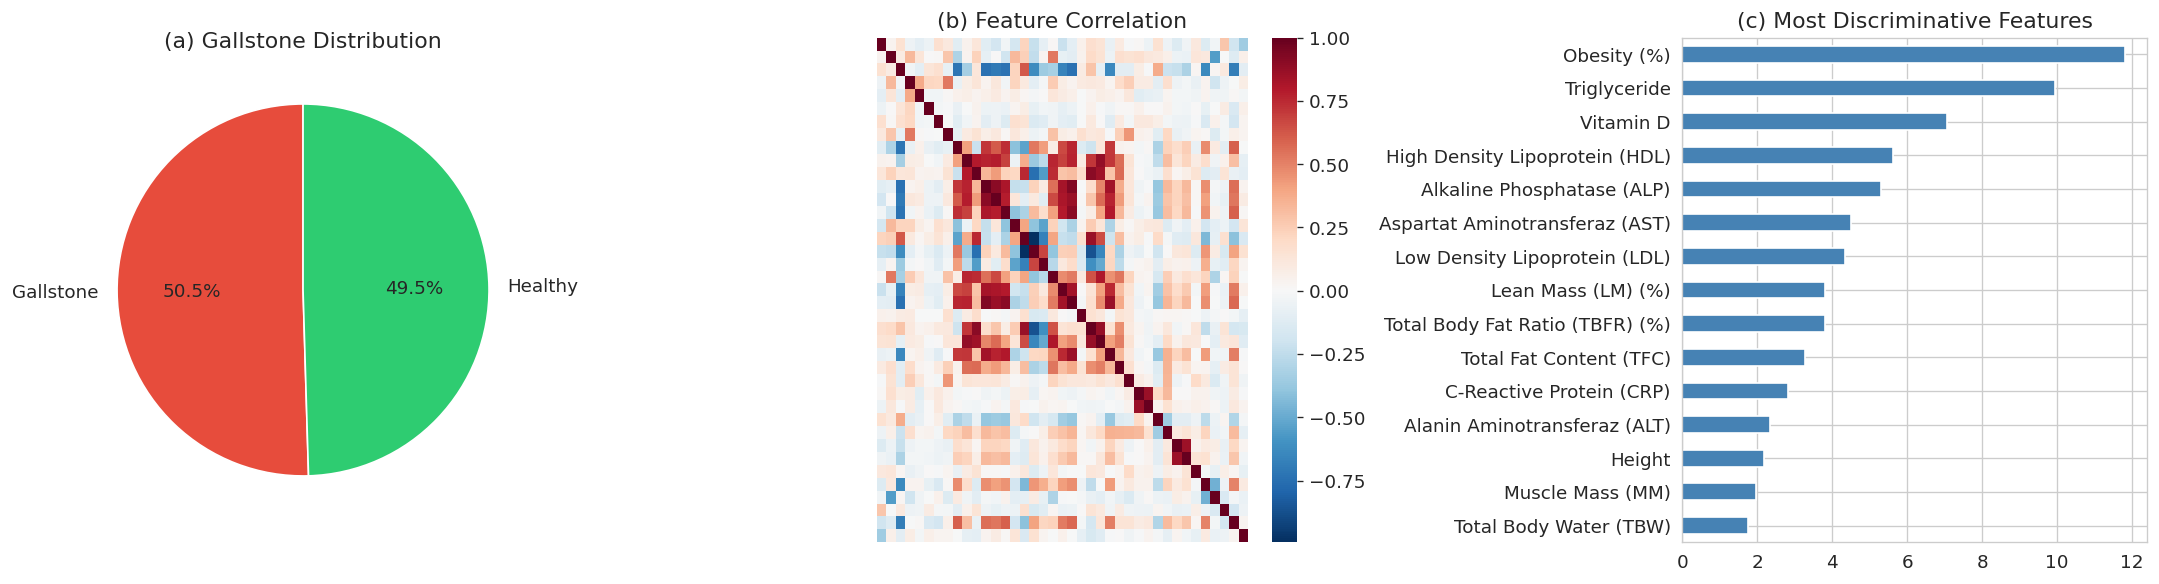

In [6]:
num_df = df.select_dtypes(include=np.number)

fig, axes = plt.subplots(1,3,figsize=(18,5))

# -----------------------
# (a) Class Distribution
# -----------------------
class_counts = y.value_counts().sort_index()

axes[0].pie(
    class_counts,
    labels=["Gallstone","Healthy"],
    autopct="%1.1f%%",
    colors=["#e74c3c","#2ecc71"],
    startangle=90
)

axes[0].set_title("(a) Gallstone Distribution")


# -----------------------
# (b) Correlation Heatmap
# -----------------------

corr = num_df.corr()

sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    xticklabels=False,
    yticklabels=False,
    ax=axes[1]
)

axes[1].set_title("(b) Feature Correlation")


# -----------------------
# (c) Top Mean Difference
# -----------------------

grp = num_df.groupby(target).mean()

diff = (grp.iloc[0]-grp.iloc[1]).abs()

diff.sort_values(ascending=False).head(15).sort_values().plot.barh(
    ax=axes[2],
    color="steelblue"
)

axes[2].set_title("(c) Most Discriminative Features")

plt.tight_layout()
plt.show()

In [7]:
# Remove zero variance features
zero_var = X.columns[X.std()==0]

X = X.drop(columns=zero_var)

# Remove highly correlated variables

corr = X.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape),1).astype(bool))

drop_cols = [c for c in upper.columns if any(upper[c]>0.95)]

X = X.drop(columns=drop_cols)

print("Remaining Features :",X.shape[1])

Remaining Features : 37


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

In [10]:
# ===============================
# Evaluation Function
# ===============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import time

def evaluate(model, X_train, X_test, y_train, y_test, model_name):

    start = time.time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    end = time.time()

    return {
        "Model":model_name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1-Score":f1_score(y_test,y_pred),
        "ROC-AUC":roc_auc_score(y_test,y_prob),
        "Time (s)":round(end-start,2)
    }

In [34]:
# ===============================
# Machine Learning Models
# ===============================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "SVM":
        SVC(
            kernel='rbf',
            probability=True,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            random_state=42
        ),

    "XGBoost":
        xgb.XGBClassifier(
            n_estimators=500,
            random_state=42,
            eval_metric='logloss'
        ),

    "LightGBM":
        lgb.LGBMClassifier(
            n_estimators=500,
            random_state=42,
            verbose=-1
        ),

    "CatBoost":
        CatBoostClassifier(
            iterations=500,
            random_state=42,
            verbose=0
        )
}

In [35]:
# ===============================
# Train All Models
# ===============================

results=[]

for name,model in models.items():

    res=evaluate(
        model,
        X_train_s,
        X_test_s,
        y_train,
        y_test,
        name
    )

    results.append(res)

results_df=pd.DataFrame(results)

results_df=results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.reset_index(drop=True,inplace=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Time (s)
0,LightGBM,0.875000,0.900000,0.84375,0.870968,0.912109,0.29
1,CatBoost,0.812500,0.833333,0.78125,0.806452,0.899414,2.38
2,XGBoost,0.828125,0.888889,0.75000,0.813559,0.893555,0.65
3,SVM,0.750000,0.766667,0.71875,0.741935,0.883789,0.15
4,Logistic Regression,0.796875,0.806452,0.78125,0.793651,0.881836,0.07
5,Random Forest,0.781250,0.821429,0.71875,0.766667,0.875977,4.45
6,KNN,0.687500,0.750000,0.56250,0.642857,0.728516,0.03


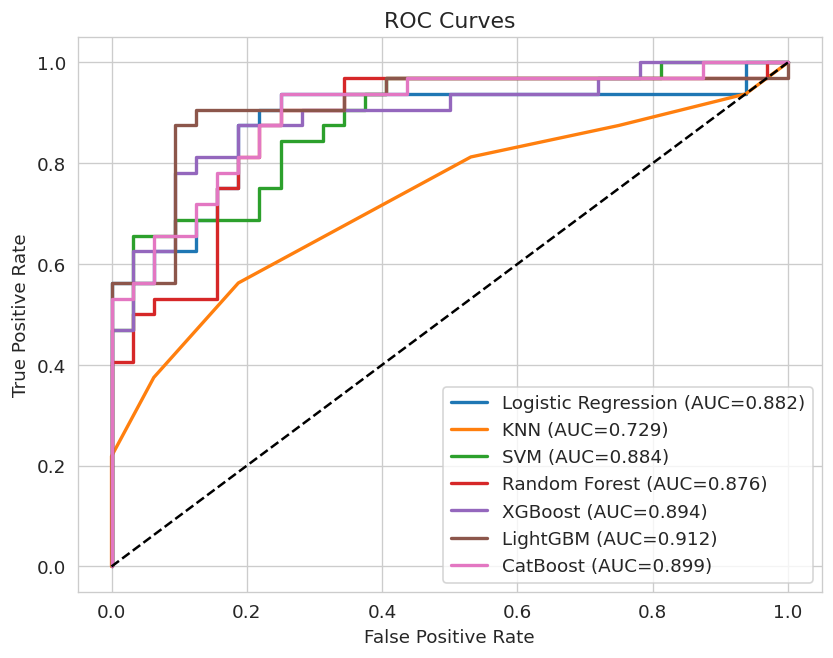

In [36]:
# ===============================
# ROC Curve
# ===============================

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name,model in models.items():

    y_prob=model.predict_proba(X_test_s)[:,1]

    fpr,tpr,_=roc_curve(y_test,y_prob)

    auc=roc_auc_score(y_test,y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.grid(True)

plt.show()

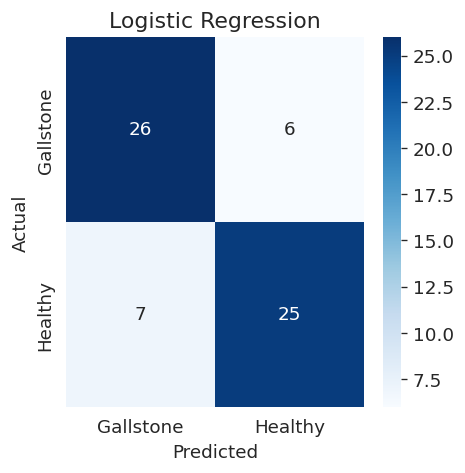

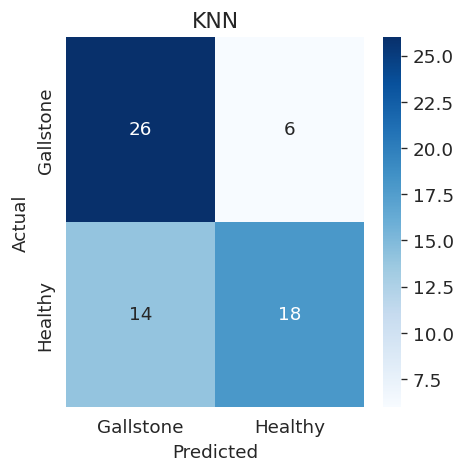

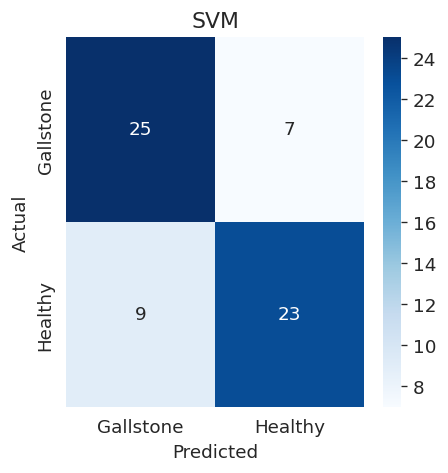

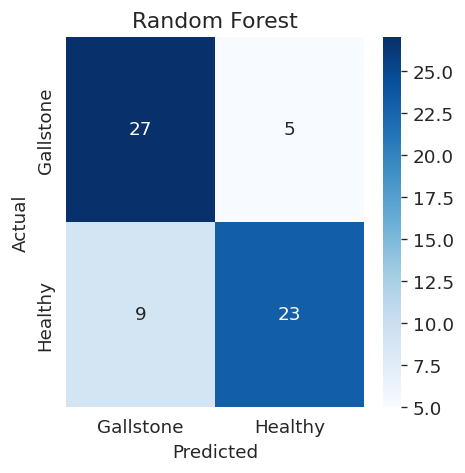

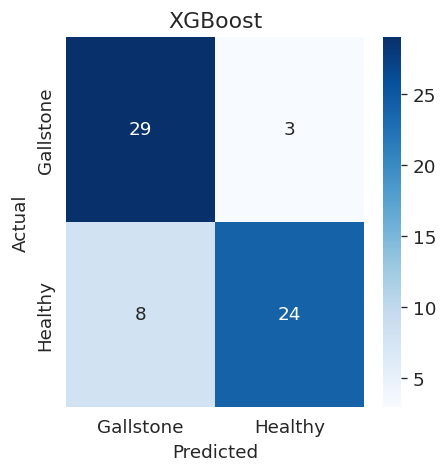

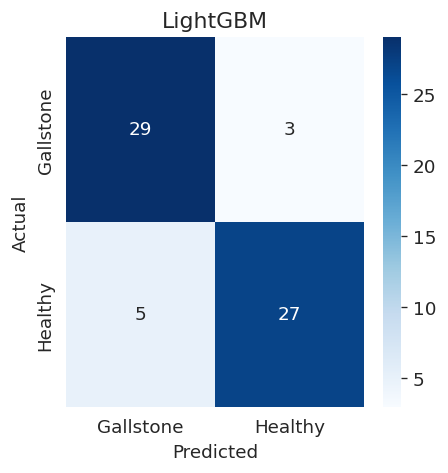

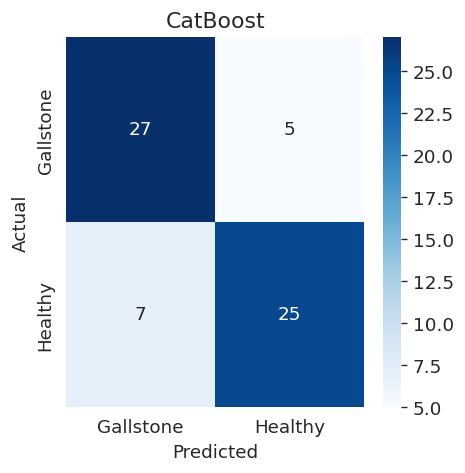

In [37]:
# ===============================
# Confusion Matrix
# ===============================

from sklearn.metrics import confusion_matrix

for name,model in models.items():

    pred=model.predict(X_test_s)

    cm=confusion_matrix(y_test,pred)

    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Gallstone','Healthy'],
        yticklabels=['Gallstone','Healthy']
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

In [38]:
# ===============================
# Classification Report
# ===============================

from sklearn.metrics import classification_report

for name,model in models.items():

    pred=model.predict(X_test_s)

    print("="*70)

    print(name)

    print("="*70)

    print(classification_report(
        y_test,
        pred,
        target_names=["Gallstone","Healthy"]
    ))

Logistic Regression
              precision    recall  f1-score   support

   Gallstone       0.79      0.81      0.80        32
     Healthy       0.81      0.78      0.79        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

KNN
              precision    recall  f1-score   support

   Gallstone       0.65      0.81      0.72        32
     Healthy       0.75      0.56      0.64        32

    accuracy                           0.69        64
   macro avg       0.70      0.69      0.68        64
weighted avg       0.70      0.69      0.68        64

SVM
              precision    recall  f1-score   support

   Gallstone       0.74      0.78      0.76        32
     Healthy       0.77      0.72      0.74        32

    accuracy                           0.75        64
   macro avg       0.75      0.75      0.75        64
weighted avg       0.75      0.75      0.75   

In [43]:
# ─── 10  fold Stratified Cross-Validation on Best Model ───
best_name = results_df.iloc[0]["Model"]
best_mdl  = models[best_name]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_mdl, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"Best Model: {best_name}")
print(f"10-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold AUC : {np.round(cv_scores, 4)}")

Best Model: LightGBM
10-Fold CV AUC: 0.8520 ± 0.0556
Per-fold AUC : [0.8225 0.7278 0.8994 0.9053 0.9408 0.8526 0.8269 0.8269 0.8718 0.8462]


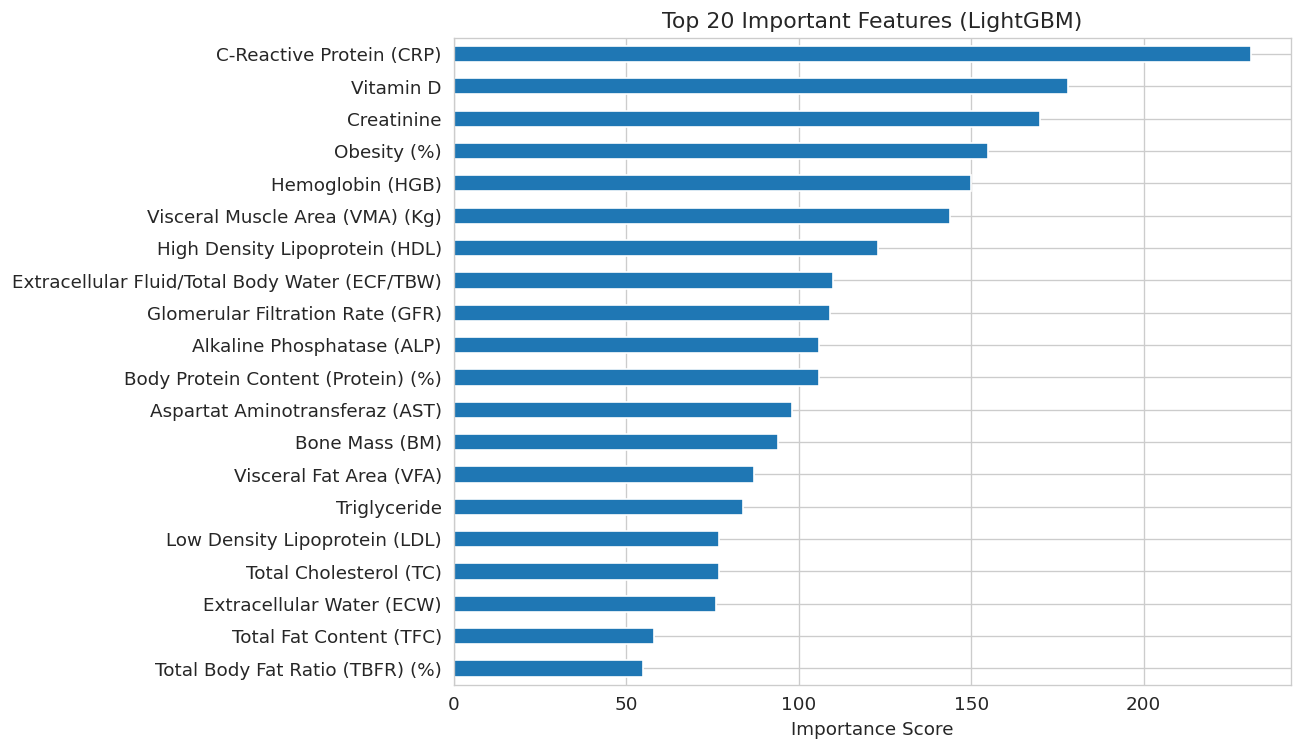

In [18]:
best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

best_model.fit(X_train_s, y_train)

if hasattr(best_model, "feature_importances_"):

    importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(9,7))

    importance.head(20).sort_values().plot.barh()

    plt.title(f"Top 20 Important Features ({best_model_name})")

    plt.xlabel("Importance Score")

    plt.show()

else:

    print(f"{best_model_name} does not provide built-in feature importance.")